
# Step 3 - Auditoria didatica do rerun M1.2

Objetivo: resumir, em um unico notebook linear, o fluxo
`RAW -> normalized -> filtered -> Step02 -> Step03 -> materialize` usando os
artefatos do rerun `m12_merge_v2`, que ja incorpora a politica
`merge_by_fdsn`.

Entradas principais:
- `outputs/catalogs/sisbra_v2024May09/sisbra_raw_normalized_m12_merge_v2_v2024May09.csv`
- `outputs/catalogs/sisbra_v2024May09/sisbra_raw_rejected_no_valid_coords_m12_merge_v2_v2024May09.csv`
- `outputs/catalogs/sisbra_v2024May09/sisbra_raw_mg_maglt4_depthlt10_yearge2020_m12_merge_v2_v2024May09.csv`
- `outputs/non_matched_audit_m12_merge_v2.csv`
- `outputs/ambiguous_events_m12_merge_v2.csv`
- `outputs/waveform_triplet_download_summary_events_m12_merge_v2.csv`
- `outputs/events_materialize_report_m12_merge_v2.csv`
- `outputs/events_duplicate_merge_report_m12_merge_v2.csv`

Este notebook e self-contained: nao importa scripts Python do repositorio e nao executa bash.


In [1]:

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)


In [2]:

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / ".git").exists():
    repo_root = repo_root.parent

if not (repo_root / ".git").exists():
    raise RuntimeError("Nao foi possivel localizar a raiz do repositorio a partir do diretorio atual.")

catalog_dir = repo_root / "outputs/catalogs/sisbra_v2024May09"
raw_normalized_csv = catalog_dir / "sisbra_raw_normalized_m12_merge_v2_v2024May09.csv"
rejected_no_coords_csv = catalog_dir / "sisbra_raw_rejected_no_valid_coords_m12_merge_v2_v2024May09.csv"
filtered_csv = catalog_dir / "sisbra_raw_mg_maglt4_depthlt10_yearge2020_m12_merge_v2_v2024May09.csv"
non_matched_csv = repo_root / "outputs/non_matched_audit_m12_merge_v2.csv"
ambiguous_csv = repo_root / "outputs/ambiguous_events_m12_merge_v2.csv"
waveform_summary_csv = repo_root / "outputs/waveform_triplet_download_summary_events_m12_merge_v2.csv"
materialize_report_csv = repo_root / "outputs/events_materialize_report_m12_merge_v2.csv"
duplicate_report_csv = repo_root / "outputs/events_duplicate_merge_report_m12_merge_v2.csv"
figures_dir = repo_root / "outputs/figures"
tables_dir = repo_root / "outputs/tables"
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

for path in [
    raw_normalized_csv,
    rejected_no_coords_csv,
    filtered_csv,
    non_matched_csv,
    ambiguous_csv,
    waveform_summary_csv,
    materialize_report_csv,
    duplicate_report_csv,
]:
    print(path.relative_to(repo_root), "->", path.exists())


outputs/catalogs/sisbra_v2024May09/sisbra_raw_normalized_m12_merge_v2_v2024May09.csv -> True
outputs/catalogs/sisbra_v2024May09/sisbra_raw_rejected_no_valid_coords_m12_merge_v2_v2024May09.csv -> True
outputs/catalogs/sisbra_v2024May09/sisbra_raw_mg_maglt4_depthlt10_yearge2020_m12_merge_v2_v2024May09.csv -> True
outputs/non_matched_audit_m12_merge_v2.csv -> True
outputs/ambiguous_events_m12_merge_v2.csv -> True
outputs/waveform_triplet_download_summary_events_m12_merge_v2.csv -> True
outputs/events_materialize_report_m12_merge_v2.csv -> True
outputs/events_duplicate_merge_report_m12_merge_v2.csv -> True


In [3]:

raw_normalized = pd.read_csv(raw_normalized_csv)
rejected_no_coords = pd.read_csv(rejected_no_coords_csv)
filtered_events = pd.read_csv(filtered_csv)
non_matched = pd.read_csv(non_matched_csv)
ambiguous_events = pd.read_csv(ambiguous_csv)
waveform_summary = pd.read_csv(waveform_summary_csv)
materialize_report = pd.read_csv(materialize_report_csv)
duplicate_report = pd.read_csv(duplicate_report_csv)

print("raw_normalized:", raw_normalized.shape)
print("rejected_no_coords:", rejected_no_coords.shape)
print("filtered_events:", filtered_events.shape)
print("non_matched:", non_matched.shape)
print("ambiguous_events:", ambiguous_events.shape)
print("waveform_summary:", waveform_summary.shape)
print("materialize_report:", materialize_report.shape)
print("duplicate_report:", duplicate_report.shape)


raw_normalized: (5934, 25)
rejected_no_coords: (144, 25)
filtered_events: (210, 28)
non_matched: (20, 31)
ambiguous_events: (1, 31)
waveform_summary: (996, 21)
materialize_report: (190, 27)
duplicate_report: (1, 16)



## 1. Contagens lineares do pipeline

Nesta etapa queremos apenas responder, em ordem: quantos eventos entram,
quantos sobrevivem ao filtro espacial/sismologico, quantos casam com FDSN,
quantos geram formas de onda e quantos finalmente entram no dataset final.


In [4]:

rows_raw_total = len(raw_normalized)
rows_valid_coords = int(raw_normalized["has_valid_latlon"].fillna(0).astype(int).eq(1).sum())
rows_invalid_coords = len(rejected_no_coords)
rows_filtered = len(filtered_events)

rows_step02_matched = len(materialize_report)
rows_step02_no_match = int((non_matched["status"] == "no_match").sum())
rows_step02_ambiguous = len(ambiguous_events)

rows_step03_triplet_tasks = len(waveform_summary)
rows_step03_downloaded = int((waveform_summary["status"] == "downloaded").sum())
rows_step03_error = int((waveform_summary["status"] == "error").sum())

rows_materialize_moved = int((materialize_report["action"] == "moved").sum())
rows_materialize_merged_duplicate = int((materialize_report["action"] == "merged_duplicate").sum())
rows_materialize_final = rows_materialize_moved

pipeline_summary = pd.DataFrame([
    {"etapa": "RAW normalizado", "contagem": rows_raw_total, "observacao": "fonte canonica apos leitura do RAW"},
    {"etapa": "Sem coordenada valida", "contagem": rows_invalid_coords, "observacao": "saem do fluxo principal e ficam auditados"},
    {"etapa": "Com coordenada valida", "contagem": rows_valid_coords, "observacao": "linhas aptas ao gate por geometria"},
    {"etapa": "Catalogo operacional filtrado", "contagem": rows_filtered, "observacao": "MG por geometria + mag < 4 + depth < 10 + year >= 2020"},
    {"etapa": "Step02 matched", "contagem": rows_step02_matched, "observacao": "eventos que encontraram um match FDSN"},
    {"etapa": "Step02 no_match", "contagem": rows_step02_no_match, "observacao": "eventos sem match FDSN"},
    {"etapa": "Step02 ambiguous", "contagem": rows_step02_ambiguous, "observacao": "eventos com mais de um candidato relevante"},
    {"etapa": "Step03 triplet_tasks", "contagem": rows_step03_triplet_tasks, "observacao": "tarefas de download de tripletos HHZ/HHN/HHE"},
    {"etapa": "Step03 downloaded", "contagem": rows_step03_downloaded, "observacao": "tarefas com download bem-sucedido"},
    {"etapa": "Step03 error", "contagem": rows_step03_error, "observacao": "tarefas que retornaram erro, principalmente HTTP 204"},
    {"etapa": "Materialize moved", "contagem": rows_materialize_moved, "observacao": "eventos finais copiados para o dataset final"},
    {"etapa": "Materialize merged_duplicate", "contagem": rows_materialize_merged_duplicate, "observacao": "bundles absorvidos por merge_by_fdsn"},
    {"etapa": "Dataset final", "contagem": rows_materialize_final, "observacao": "um diretorio final por evento FDSN materializado"},
])

display(pipeline_summary)

pipeline_summary.to_csv(tables_dir / "step3_m12_pipeline_summary_v2.csv", index=False)


,etapa,contagem,observacao
0,RAW normalizado,5934,fonte canonica apos leitura do RAW
1,Sem coordenada valida,144,saem do fluxo principal e ficam auditados
2,Com coordenada valida,5790,linhas aptas ao gate por geometria
3,Catalogo operacional filtrado,210,MG por geometria + mag < 4 + depth < 10 + year >= 2020
4,Step02 matched,190,eventos que encontraram um match FDSN
5,Step02 no_match,19,eventos sem match FDSN
6,Step02 ambiguous,1,eventos com mais de um candidato relevante
7,Step03 triplet_tasks,996,tarefas de download de tripletos HHZ/HHN/HHE
8,Step03 downloaded,823,tarefas com download bem-sucedido
9,Step03 error,173,"tarefas que retornaram erro, principalmente HTTP 204"



## 2. Visualizacao rapida das contagens principais

Os graficos abaixo nao substituem a leitura das tabelas, mas ajudam a ver
rapidamente onde o fluxo ganha ou perde cobertura.


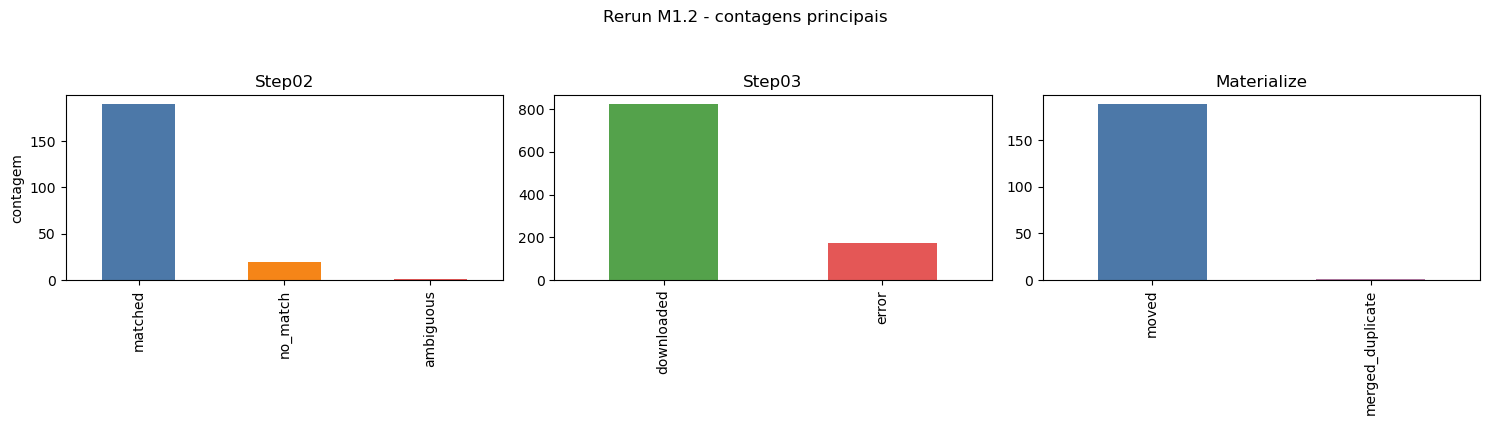

Figura salva em: outputs/figures/step3_m12_counts_v2.png


In [5]:

step02_counts = pd.Series({"matched": rows_step02_matched, "no_match": rows_step02_no_match, "ambiguous": rows_step02_ambiguous})
step03_counts = pd.Series({"downloaded": rows_step03_downloaded, "error": rows_step03_error})
materialize_counts = pd.Series({"moved": rows_materialize_moved, "merged_duplicate": rows_materialize_merged_duplicate})

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
step02_counts.plot(kind="bar", ax=axes[0], color=["#4C78A8", "#F58518", "#E45756"])
axes[0].set_title("Step02")
axes[0].set_ylabel("contagem")

step03_counts.plot(kind="bar", ax=axes[1], color=["#54A24B", "#E45756"])
axes[1].set_title("Step03")

materialize_counts.plot(kind="bar", ax=axes[2], color=["#4C78A8", "#B279A2"])
axes[2].set_title("Materialize")

fig.suptitle("Rerun M1.2 - contagens principais", y=1.05)
fig.tight_layout()
figure_path = figures_dir / "step3_m12_counts_v2.png"
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Figura salva em:", figure_path.relative_to(repo_root))



## 3. Eventos sem match e evento ambiguo

Aqui a pergunta e: o que nao entrou no dataset final porque o match FDSN
falhou, e o que precisa de investigacao manual por ambiguidade?


In [6]:

no_match_by_agency = non_matched.groupby(["is_critical_agency", "sisbra_agency_tag_normalized"]).size().reset_index(name="event_count")
no_match_by_agency = no_match_by_agency.sort_values(
    ["is_critical_agency", "event_count", "sisbra_agency_tag_normalized"],
    ascending=[False, False, True],
).reset_index(drop=True)

display(no_match_by_agency)

critical_no_match = non_matched[non_matched["is_critical_agency"] == 1][[
    "event_folder",
    "sisbra_origin_time",
    "sisbra_state",
    "sisbra_magnitude",
    "sisbra_latitude",
    "sisbra_longitude",
    "sisbra_localities",
    "sisbra_agency_tag_normalized",
    "match_error",
]].copy()
display(critical_no_match.head(10))

print("Evento ambiguo registrado no rerun:")
display(ambiguous_events[[
    "event_folder",
    "sisbra_origin_time",
    "candidate_count",
    "best_dt_s",
    "best_dist_km",
    "alt_dt_s",
    "alt_dist_km",
    "sisbra_localities",
    "sisbra_agency_tag_normalized",
]])

no_match_by_agency.to_csv(tables_dir / "step3_m12_no_match_by_agency_v2.csv", index=False)


,is_critical_agency,sisbra_agency_tag_normalized,event_count
0,1,USP,3
1,1,RSVL USP UNB,1
2,0,UNB,14
3,0,UFRN,2


,event_folder,sisbra_origin_time,sisbra_state,sisbra_magnitude,sisbra_latitude,sisbra_longitude,sisbra_localities,sisbra_agency_tag_normalized,match_error
0,20200722T180000_row24,2020-07-22T18:00:00Z,MG,0.0,-22.45,-45.44,Itajubá,USP,no_data: No data available for request.\nHTTP Status code: 204\nDetailed response of server:\n\n
1,20201002T202619_row33,2020-10-02T20:26:19Z,MG,2.6,-21.00,-44.63,Bom Sucesso,RSVL USP UNB,no_data: No data available for request.\nHTTP Status code: 204\nDetailed response of server:\n\n
2,20210122T085500_row41,2021-01-22T08:55:00Z,MG,2.0,-16.73,-43.86,Montes Claros,USP,no_data: No data available for request.\nHTTP Status code: 204\nDetailed response of server:\n\n
3,20221228T135247_row161,2022-12-28T13:52:47Z,MG,1.7,-19.51,-44.22,Sete Lagoas,USP,no_data: No data available for request.\nHTTP Status code: 204\nDetailed response of server:\n\n


Evento ambiguo registrado no rerun:


,event_folder,sisbra_origin_time,candidate_count,best_dt_s,best_dist_km,alt_dt_s,alt_dist_km,sisbra_localities,sisbra_agency_tag_normalized
0,20210424T173443_usp2021hzuo_row48,2021-04-24T17:34:43Z,2,0.909999,3.007839,0.909999,3.007839,ITABIRA,UNB



## 4. Triagem rapida dos erros do Step03

O objetivo aqui nao e resolver todos os `HTTP 204`, mas deixar claro onde
eles se concentram para a proxima rodada de investigacao.


In [7]:
step03_errors = waveform_summary[waveform_summary["status"] == "error"].copy()
step03_errors["error_short"] = step03_errors["error"].fillna("").astype(str).str.split("\n").str[0]

errors_by_station = step03_errors.groupby(["network", "station", "channel", "error_short"]).size().reset_index(name="error_count")
errors_by_station = errors_by_station.sort_values("error_count", ascending=False).reset_index(drop=True)

errors_by_network = step03_errors.groupby("network").size().reset_index(name="error_count")
errors_by_network = errors_by_network.sort_values("error_count", ascending=False).reset_index(drop=True)

display(errors_by_network)
display(errors_by_station.head(20))

errors_by_station.to_csv(tables_dir / "step3_m12_http204_by_station_v2.csv", index=False)
errors_by_network.to_csv(tables_dir / "step3_m12_http204_by_network_v2.csv", index=False)


,network,error_count
0,VL,141
1,ON,30
2,G,1
3,BX,1


,network,station,channel,error_short,error_count
0,VL,GNG4,HH3,No data available for request.,37
1,VL,FABR,HH3,No data available for request.,29
2,ON,CAM01,HH3,No data available for request.,27
3,VL,AGLP,HH3,No data available for request.,27
4,VL,CHCR,HH3,No data available for request.,16
5,VL,GNG6,HH3,No data available for request.,15
6,VL,FJAO,HH3,No data available for request.,10
7,VL,FZND,HH3,No data available for request.,5
8,ON,CMC01,HH3,No data available for request.,3
9,VL,EARZ,HH3,No data available for request.,2



## 5. Impacto da deduplicacao no dataset final

A deduplicacao nao alterou o numero de matches do Step02. Ela apenas evitou
que duas linhas SISBRA do mesmo `fdsn.resource_id` gerassem colisao de pasta
na materializacao final.


In [8]:

display(duplicate_report)

materialize_actions = materialize_report.groupby("action").size().reset_index(name="event_count")
materialize_actions = materialize_actions.sort_values("event_count", ascending=False).reset_index(drop=True)
display(materialize_actions)

materialize_actions.to_csv(tables_dir / "step3_m12_materialize_actions_v2.csv", index=False)


,merge_key,merge_key_type,target_folder,canonical_source_folder,canonical_rownum,canonical_rownum_source,canonical_match_dt_s,canonical_match_dist_km,duplicate_source_folder,duplicate_rownum,duplicate_rownum_source,duplicate_match_dt_s,duplicate_match_dist_km,group_size,merge_status,notes
0,smi:org.gfz-potsdam.de/geofon/usp2021flcy,fdsn.resource_id,2021078T053957,20210319T053957_usp2021flcy_row44,44,4875,0.113955,2.147325,20210319T053957_usp2021flcy_row45,45,4878,0.886045,4.709782,2,merged_duplicate,same_fdsn_resource_id


,action,event_count
0,moved,189
1,merged_duplicate,1



## 6. Conclusoes

- O rerun M1.2 fecha com `5934` linhas RAW normalizadas, `144` rejeitadas por falta de coordenada e `210` eventos no catalogo operacional.
- O Step02 divide esses `210` eventos em `190 matched`, `19 no_match` e `1 ambiguous`.
- O Step03 gera `996` tarefas, com `823` downloads e `173` erros, que agora ficam prontos para triagem por rede, estacao e canal.
- O materialize finaliza com `189` eventos no dataset final e `1` bundle absorvido por `merge_by_fdsn`.
- O proximo passo tecnico natural e aprofundar a triagem dos `HTTP 204` e transformar estas auditorias em material de discussao com os professores.
